In [22]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [23]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

In [24]:
df_train = df_train[df_train['emotion'].isin(['angry', 'happy', 'sad'])]
df_val   = df_val[df_val['emotion'].isin(['angry', 'happy', 'sad'])]
df_test  = df_test[df_test['emotion'].isin(['angry', 'happy', 'sad'])]

In [25]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    max_len = 3 * sr
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_mel = librosa.power_to_db(mel)

    delta = librosa.feature.delta(log_mel)
    delta2 = librosa.feature.delta(log_mel, order=2)

    combined = np.stack([log_mel, delta, delta2], axis=-1)  # (128, T, 3)

    return combined

In [26]:
def process_dataframe(df):
    X, y = [], []

    for _, row in df.iterrows():
        file_path = row['path']
        label = row['emotion']

        try:
            features = extract_features(file_path)
            X.append(features)
            y.append(label)
        except:
            continue

    return np.array(X), np.array(y)

In [27]:
X_train, y_train = process_dataframe(df_train)
X_val, y_val     = process_dataframe(df_val)
X_test, y_test   = process_dataframe(df_test)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (3084, 128, 130, 3)
Val: (621, 128, 130, 3)
Test: (684, 128, 130, 3)


In [28]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

In [29]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_val_cat   = to_categorical(y_val_enc)
y_test_cat  = to_categorical(y_test_enc)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

model = Sequential()

# 🔹 Conv Block 1
model.add(Conv2D(32, (3,3), activation='relu',
                 kernel_regularizer=l2(0.001),
                 input_shape=(128, X_train.shape[2], 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# 🔹 Conv Block 2
model.add(Conv2D(64, (3,3), activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# 🔹 Conv Block 3
model.add(Conv2D(128, (3,3), activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# 🔥 Replace Flatten with GAP (important)
model.add(GlobalAveragePooling2D())

# 🔹 Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# 🔹 Output Layer
model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 126, 128, 32)      896       
                                                                 
 batch_normalization_4 (Bat  (None, 126, 128, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 63, 64, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 61, 62, 64)        18496     
                                                                 
 batch_normalization_5 (Bat  (None, 61, 62, 64)        256       
 chNormalization)                                                
                                                      

In [31]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [33]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/40
97/97 [==============================] - 23s 224ms/step - loss: 0.9499 - accuracy: 0.6145 - val_loss: 1.1815 - val_accuracy: 0.4251 - lr: 5.0000e-04
Epoch 2/40
97/97 [==============================] - 23s 234ms/step - loss: 0.8790 - accuracy: 0.6556 - val_loss: 1.2502 - val_accuracy: 0.4428 - lr: 5.0000e-04
Epoch 3/40
97/97 [==============================] - 22s 231ms/step - loss: 0.8315 - accuracy: 0.6774 - val_loss: 1.2215 - val_accuracy: 0.4686 - lr: 5.0000e-04
Epoch 4/40
97/97 [==============================] - 23s 234ms/step - loss: 0.8034 - accuracy: 0.6890 - val_loss: 1.4087 - val_accuracy: 0.4686 - lr: 5.0000e-04
Epoch 5/40
97/97 [==============================] - 23s 235ms/step - loss: 0.7487 - accuracy: 0.7228 - val_loss: 1.2200 - val_accuracy: 0.4928 - lr: 1.5000e-04
Epoch 6/40
97/97 [==============================] - 23s 236ms/step - loss: 0.7166 - accuracy: 0.7471 - val_loss: 1.0621 - val_accuracy: 0.5700 - lr: 1.5000e-04
Epoch 7/40
97/97 [======================

In [34]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print(" CNN Accuracy:", test_acc)

22/22 [==============================] - 1s 52ms/step - loss: 0.5339 - accuracy: 0.8260
 CNN Accuracy: 0.8260233998298645


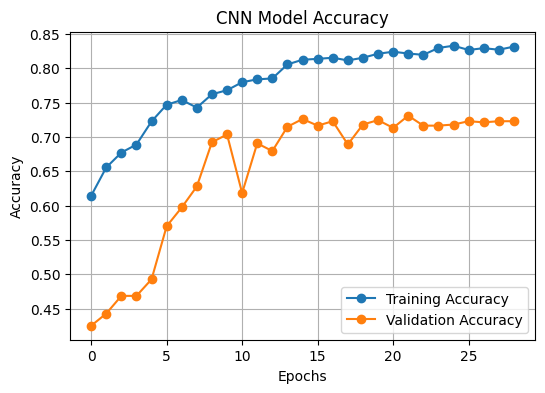

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.savefig('cnn_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

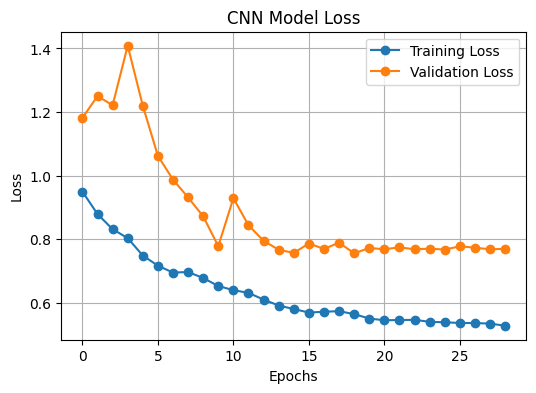

In [36]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])
plt.grid(True)

plt.savefig('cnn_loss.png', dpi=300, bbox_inches='tight')
plt.show()

22/22 [==============================] - 1s 51ms/step


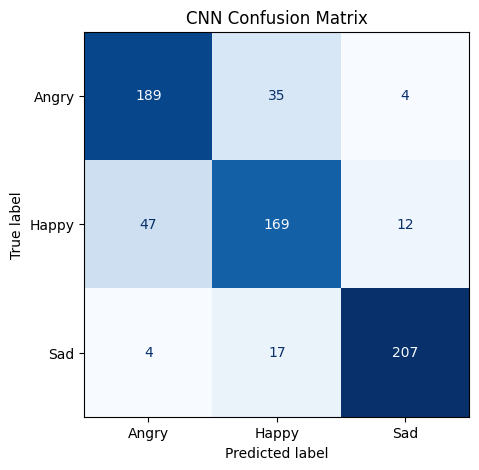

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = np.argmax(y_test_cat, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

labels = ['Angry', 'Happy', 'Sad']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('CNN Confusion Matrix')
plt.savefig('cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=['Angry', 'Happy', 'Sad']
)

print(report)

              precision    recall  f1-score   support

       Angry       0.79      0.83      0.81       228
       Happy       0.76      0.74      0.75       228
         Sad       0.93      0.91      0.92       228

    accuracy                           0.83       684
   macro avg       0.83      0.83      0.83       684
weighted avg       0.83      0.83      0.83       684



In [39]:
import pandas as pd

report_dict = classification_report(
    y_true,
    y_pred_classes,
    target_names=['Angry', 'Happy', 'Sad'],
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
print(df_report)

              precision    recall  f1-score     support
Angry          0.787500  0.828947  0.807692  228.000000
Happy          0.764706  0.741228  0.752784  228.000000
Sad            0.928251  0.907895  0.917960  228.000000
accuracy       0.826023  0.826023  0.826023    0.826023
macro avg      0.826819  0.826023  0.826145  684.000000
weighted avg   0.826819  0.826023  0.826145  684.000000


In [40]:
print(" Training Accuracy:", history.history['accuracy'][-1])

 Training Accuracy: 0.8317120671272278


In [41]:
print(" Validation Accuracy:", max(history.history['val_accuracy']))

 Validation Accuracy: 0.7310789227485657


In [42]:
model.save("cnn_model.h5")   

c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [43]:
mean = np.mean(X_train)
std = np.std(X_train)

import json
json.dump({"mean": float(mean), "std": float(std)}, open("norm.json", "w"))